# Artificial Intelligence and Society 2024/2025
### Individual Assignment 4: Missing Data

**Author:** Adriano Machado (FEUP/FCUP)

## Introduction

This assignment has the goal of investigating the impact of different missing data mechanisms (MCAR, MAR, MNAR) on the performance of different algorithms and explores the effectiveness of various missing data handling strategies.

For this, we'll use three datasets without missing values and artificially introduce missing values in them. We'll then select among several approaches to handle missing data (e.g., classifying with missing values, performing data imputation) and compare the obtained performance across different approaches.

## Datasets

- [Diabetes](https://scikit-learn.org/1.5/modules/generated/sklearn.datasets.load_diabetes.html) - The Diabetes Dataset consists of ten baseline variables: age, sex, body mass index, average blood pressure, and six blood serum measurements. These were obtained for each of 442 diabetes patients. The target is a quantitative measure of disease progression one year after baseline.



In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd

load_diabetes_data = load_diabetes()
df_diabetes = pd.DataFrame(load_diabetes_data.data, columns=load_diabetes_data.feature_names)


X_diabetes = df_diabetes
y_diabetes = load_diabetes_data.target
df_diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [2]:
df_diabetes.describe().T

,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.293722e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


Let's investigate the distributions of individual features using histograms.

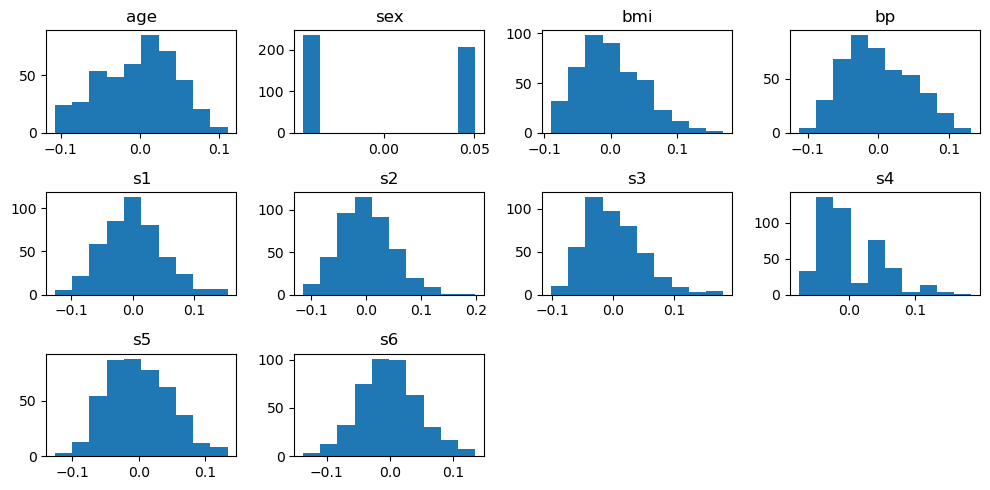

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for i, col in enumerate(df_diabetes.columns):
    plt.subplot(3, 4, i + 1)
    plt.hist(df_diabetes[col])
    plt.title(col)
plt.tight_layout()
plt.show()

We'll also examine the relationships between features and the target variable using correlation coefficients and visualizations.

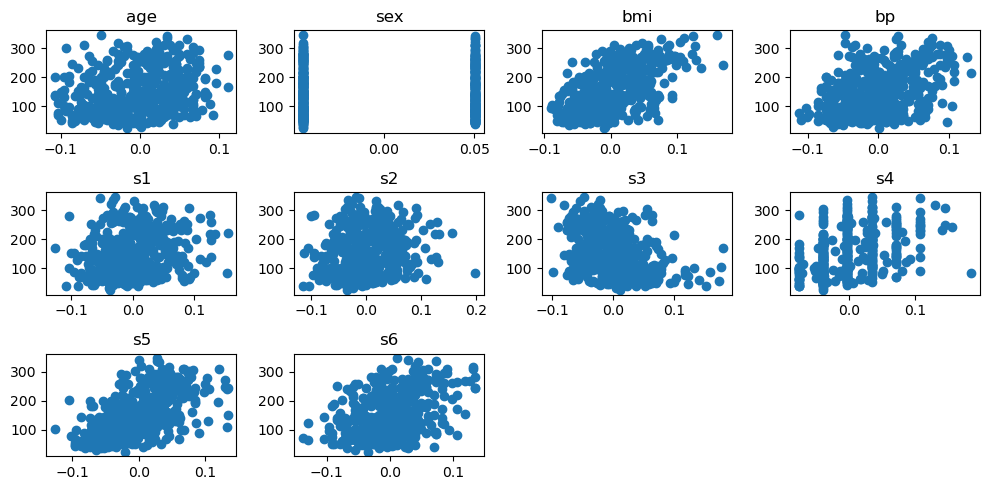

age    0.187889
sex    0.043062
bmi    0.586450
bp     0.441482
s1     0.212022
s2     0.174054
s3    -0.394789
s4     0.430453
s5     0.565883
s6     0.382483
dtype: float64


In [4]:
y_diabetes_series = pd.Series(y_diabetes)

plt.figure(figsize=(10, 5))
for i, col in enumerate(df_diabetes.columns):
    plt.subplot(3, 4, i + 1)
    plt.scatter(df_diabetes[col], y_diabetes)
    plt.title(col)
plt.tight_layout()
plt.show()

print(df_diabetes.corrwith(y_diabetes_series))


BMI, BP, S4, S5, and S6 showed moderate to strong correlations with the target variable

All of these variables are numerical and don't have missing values, thus we can skip the data preprocessing step.

- [Abalone](https://archive.ics.uci.edu/dataset/1/abalone) - Predicting the age of abalone from physical measurements.  

In [5]:
abalone_path = 'datasets/abalone/abalone.csv'
abalone_names = ['sex', 'length', 'diameter', 'height', 'whole_weight', 'shucked_weight', 'viscera_weight', 'shell_weight', 'rings']
df_abalone = pd.read_csv(abalone_path, names=abalone_names)

df_abalone.head()

,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [6]:
print("\nAbalone Dataset Describe:")
df_abalone.describe().T


Abalone Dataset Describe:


,count,mean,std,min,25%,50%,75%,max
length,4177.0,0.523992,0.120093,0.0750,0.4500,0.5450,0.615,0.8150
diameter,4177.0,0.407881,0.099240,0.0550,0.3500,0.4250,0.480,0.6500
height,4177.0,0.139516,0.041827,0.0000,0.1150,0.1400,0.165,1.1300
whole_weight,4177.0,0.828742,0.490389,0.0020,0.4415,0.7995,1.153,2.8255
shucked_weight,4177.0,0.359367,0.221963,0.0010,0.1860,0.3360,0.502,1.4880
viscera_weight,4177.0,0.180594,0.109614,0.0005,0.0935,0.1710,0.253,0.7600
shell_weight,4177.0,0.238831,0.139203,0.0015,0.1300,0.2340,0.329,1.0050
rings,4177.0,9.933684,3.224169,1.0000,8.0000,9.0000,11.000,29.0000


Let's investigate the distributions of individual features using histograms.

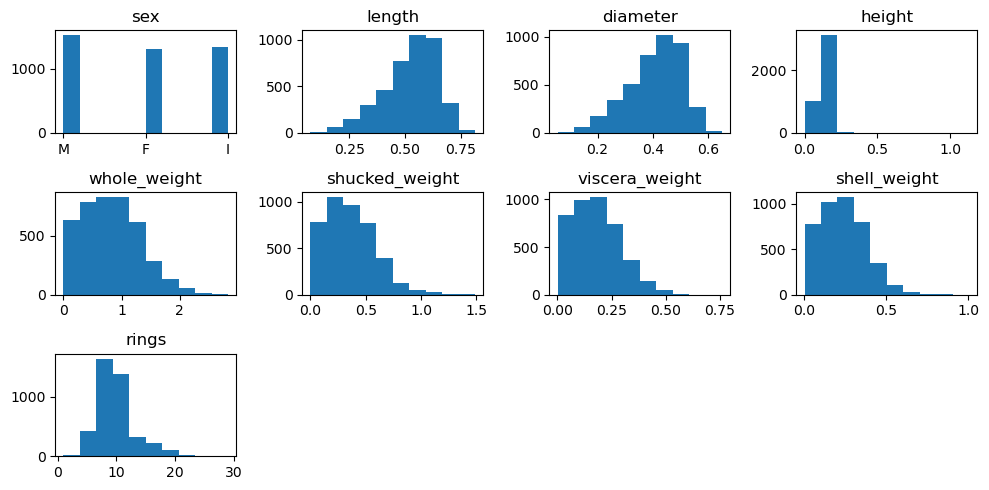

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for i, col in enumerate(df_abalone.columns):
    plt.subplot(3, 4, i + 1)
    plt.hist(df_abalone[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Let's use one-hot encoding to transform the sex variable. 

In [8]:
df_abalone = pd.get_dummies(df_abalone, columns=['sex'])
df_abalone.head()

,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings,sex_F,sex_I,sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,False,False,True
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,False,False,True
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,True,False,False
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,False,False,True
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,False,True,False


In [9]:
X_abalone = df_abalone.drop('rings', axis=1)
y_abalone = df_abalone['rings']

y_abalone = y_abalone.values


## Missing Data Mechanisms

Missing data mechanisms describe how the probability of a missing values related to the data, if at all


*   **Missing Completely At Random (MCAR):** Missingness is unrelated to *any* observed or unobserved data. The absence of data occurs randomly, without any discernible pattern 
    *   Example: A survey respondent unintentionally skips a question
    <!-- *   Is easily handled with simple methods like listwise deletion or mean imputation; -->

*   **Missing At Random (MAR):** The missingness can be explained by some observed features in the dataset. Although the data is missing systematically, it is still considered random because the missingness is not related to the unobserved values.
    *   Example: In a tobacco study, younger participants might report their values less often (regardless of how much they smoke), leading to systematic missingness for age-related reasons
    *   Requires more sophisticated handling techniques like multiple imputation or maximum likelihood estimation;

*   **Missing Not At Random (MNAR):** Missingness is non-random and depends on the missing variable itself or other unobserved data. 
    *   Example: Referring to the tobacco study example, participants who smoke the most might intentionally withhold their smoking habits, leading to systematic missingness related to the missing data.
    *   Is the most challenging to handle, as the reasons for missingness are not captured within the observed data;

In order to simulate these mechanisms in our datasets, we'll use the [`mdatagen library`](https://arthurmangussi.github.io/pymdatagen/).

In [10]:
from missingno import missingno as msno

def visualize_missing_data_missingno(data_missing, data_original, mechanism_name, dataset_name, visualization_type="matrix", col_missing=None, cols_scatter=None, ax=None):
    """
    Visualizes missing data patterns using the missingno module and matplotlib for scatterplot.

    Args:
        data_missing (pd.DataFrame): Dataset with missing values.
        data_original (pd.DataFrame): Original complete dataset. # Added data_original as it might be useful for scatterplot context
        mechanism_name (str): Name of the missing data mechanism (for title).
        dataset_name (str): Name of the dataset (for title).
        visualization_type (str, optional): Type of visualization
            ('matrix', 'bar', 'dendrogram', 'heatmap', 'scatterplot').
            Defaults to "matrix".
        col_missing (str, optional): Column name for visualizations (not directly used by missingno in this example, but kept for consistency). Defaults to None.
        cols_scatter (tuple, optional): Column names (x, y) for 'scatterplot'. Defaults to None.
        ax (matplotlib.axes._axes.Axes, optional):  Axes object to plot on. Defaults to None, which creates a new figure and axes.

    Returns:
        matplotlib.axes._axes.Axes: The matplotlib Axes object after visualization.
    """

    visualization_types_missingno = ["matrix", "bar", "dendrogram", "heatmap"]
    visualization_types_all = visualization_types_missingno + ["scatterplot"]


    if visualization_type not in visualization_types_all:
        raise ValueError(f"Invalid visualization_type: {visualization_type}. Choose from {', '.join(visualization_types_all)}.")

    if visualization_type == "scatterplot":
        if cols_scatter is None:
            raise ValueError(f"For 'scatterplot', cols_scatter must be specified as a tuple (col_x, col_y).")
        return _geom_miss_plot_missingno(data_missing, cols_scatter, mechanism_name, dataset_name, ax=ax) 
    elif visualization_type in visualization_types_missingno:
        if visualization_type == "matrix":
            ax_msno = msno.matrix(data_missing, ax=ax, sparkline=False)
        elif visualization_type == "bar":
            ax_msno = msno.bar(data_missing, ax=ax)
        elif visualization_type == "dendrogram":
            ax_msno = msno.dendrogram(data_missing, ax=ax)
        elif visualization_type == "heatmap":
            ax_msno = msno.heatmap(data_missing, ax=ax)

        if ax_msno is not None: 
            ax_msno.set_title(f"{visualization_type.capitalize()} Plot - {mechanism_name} - {dataset_name}")
        return ax_msno
    else:
        raise ValueError(f"Invalid visualization_type: {visualization_type}. Choose from {', '.join(visualization_types_missingno)} or 'scatterplot'.")


def _geom_miss_plot_missingno(data_missing, cols:tuple[str, str], mechanism_name, dataset_name, threshold:tuple[float,float,float]=(0.5, 0.8, 0.9), ax=None):
    col_x, col_y = cols
    df_aux = pd.DataFrame(columns=[col_x,col_y])
    df_aux[[col_x, col_y]] = data_missing[[col_x, col_y]].copy()
    df_aux['Indicator'] = df_aux[[col_x, col_y]].isna().any(axis=1).map({True:"Missing", False: "Not Missing"})

    min_values = df_aux[[col_x, col_y]].min()
    for col in [col_x, col_y]:
        if df_aux[col].isna().any():
            min_val = min_values[col]
            offset_range = (threshold[0] * min_val, threshold[1] * min_val)
            df_aux[col] = df_aux[col].apply(lambda value: np.random.uniform(offset_range[0], offset_range[1]) if pd.isna(value) else value)


    if ax is None:
        fig, ax = plt.subplots() 

    missing_data = df_aux[df_aux['Indicator'] == 'Missing']
    not_missing_data = df_aux[df_aux['Indicator'] == 'Not Missing']

    ax.scatter(not_missing_data[col_x], not_missing_data[col_y], label='Not Missing', color='blue', alpha=0.7) 
    ax.scatter(missing_data[col_x], missing_data[col_y], label='Missing', color='red', alpha=0.7)


    ax.set_xlabel(col_x)
    ax.set_ylabel(col_y)
    ax.legend()
    ax.axvline(x=threshold[2] * min_values[col_x], color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
    ax.axhline(y=threshold[2] * min_values[col_y], color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
    ax.set_title(f"Scatterplot - {mechanism_name} - {dataset_name}")

    return ax

def plot_mechanisms_missingno(data_original, mechanisms_df_dict, visualization_type, cols_scatter=None, x_obs_param=None, figsize=(12, 6)):
    fig, axes = plt.subplots(len(visualization_type), len(mechanisms_df_dict), figsize=figsize)
    for i, visualization_type in enumerate(visualization_type):
        for j, mechanism in enumerate(mechanisms_df_dict.keys()):
            df_missing = mechanisms_df_dict[mechanism]
            ax = axes[i, j]
            visualize_missing_data_missingno(
                data_missing=df_missing,
                data_original=data_original,
                mechanism_name=mechanism.upper(),
                dataset_name="Diabetes",
                visualization_type=visualization_type,
                cols_scatter=cols_scatter,
                ax=ax
            )

            if i == 0:
                ax.set_title(f"Mechanism: {mechanism.upper()}")

            if j == 0:
                ax.set_ylabel(f"Visualization: {visualization_type.capitalize()}", rotation=90, labelpad=20)

    plt.tight_layout()
    plt.show()

#### Diabetes Dataset - Missing Data Mechanisms

In [11]:
from mdatagen.multivariate.mMCAR import mMCAR
from mdatagen.multivariate.mMAR import mMAR
from mdatagen.multivariate.mMNAR import mMNAR
"""
Args:
    X (pd.DataFrame): The dataset to receive the missing data.
    y (np.array): The label values from dataset
    missing_rate (int, optional): The rate of missing data to be generated. Default is 10.
    missTarget (bool, optional): A flag to generate missing into the target.
    seed (int, optional): The seed for the random number generator.
"""
generator = mMCAR(X=X_diabetes, y=y_diabetes, missing_rate=10, missTarget=False, seed=42)
df_diabetes_mcar = generator.random()

"""    
Args:
    X (pd.DataFrame): The dataset to receive the missing data.
    y (np.array): The label values from dataset
    n_xmiss (int): The number of features in the dataset that will receive missing values. Default is 2.
    missTarget (bool, optional): A flag to generate missing into the target.
"""
generator = mMAR(X=X_diabetes, y=y_diabetes, missTarget=False)
df_diabetes_mar = generator.random(missing_rate = 10)

"""
Args:
    X (pd.DataFrame): The dataset to receive the missing data.
    y (np.array): The label values from dataset
Keyword Args:
    n_xmiss (int, optional): The number of features in the dataset that will receive missing values. Default is the number of features in dataset.
    threshold (float, optional): The threshold to select the locations in feature (xmiss) to receive missing values where 0 indicates de lowest and 1 highest values. Default is 0
    missTarget (bool, optional): A flag to generate missing into the target.
"""
generator = mMNAR(X=X_diabetes, y=y_diabetes, missTarget=False)
df_diabetes_mnar = generator.random(missing_rate = 10)

In [12]:
READ_ONLY = True
if not READ_ONLY:
    
    df_diabetes_mcar.to_csv('datasets/diabetes/diabetes_mcar.csv', index=False)
    df_diabetes_mar.to_csv('datasets/diabetes/diabetes_mar.csv', index=False)
    df_diabetes_mnar.to_csv('datasets/diabetes/diabetes_mnar.csv', index=False)
else:
    df_diabetes_mcar = pd.read_csv('datasets/diabetes/diabetes_mcar.csv')
    df_diabetes_mar = pd.read_csv('datasets/diabetes/diabetes_mar.csv')
    df_diabetes_mnar = pd.read_csv('datasets/diabetes/diabetes_mnar.csv')

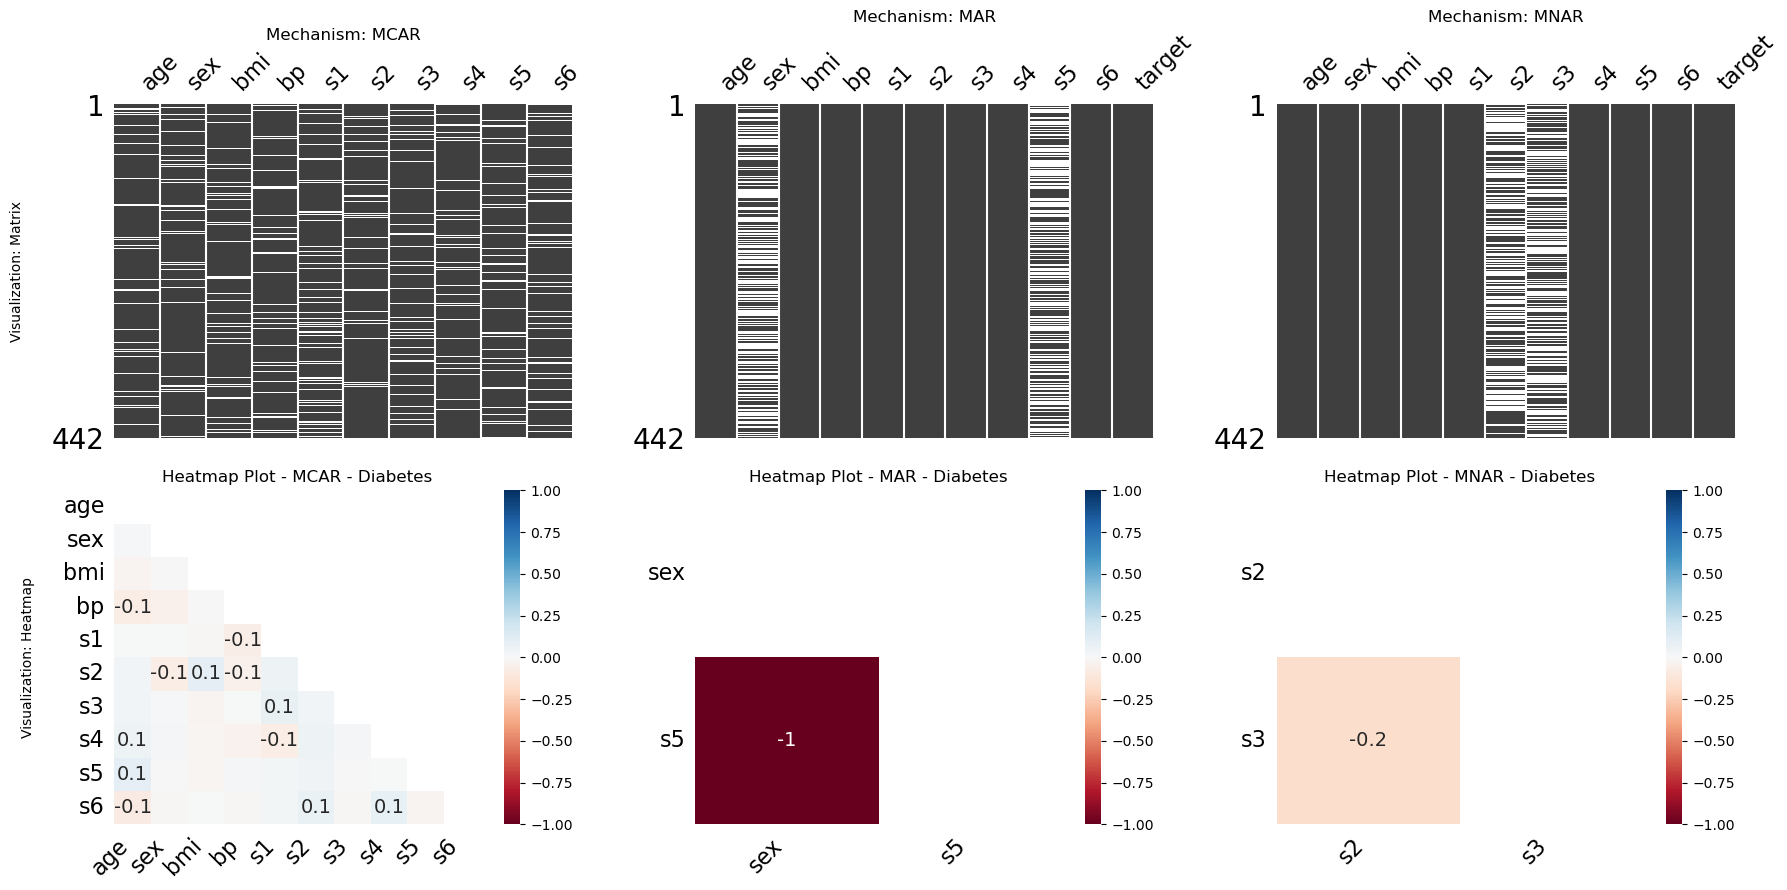

In [13]:
plot_mechanisms_missingno(df_diabetes, 
                          mechanisms_df_dict={"MCAR": df_diabetes_mcar, "MAR": df_diabetes_mar, "MNAR": df_diabetes_mnar}, 
                          visualization_type=["matrix", "heatmap"], 
                          cols_scatter=('bmi', 'bp'),
                          figsize=(18, 9))

As we can see in the plots above, 
- MCAR (1st col): The missing values are randomly distributed across the dataset. No patterns in the matrix, no significant correlations in the heatmap
- MAR (2nd col): The missingness is related to other observed features in the dataset. In this case the s5 and the sex features are negatively correlated (when one is missing, the other is present)
- MNAR (3rd col): Missingness is non-random and depends on the missing variable itself or other unobserved data. In this case the s3 and s2 features are moderately correlated, this is expected since it also depends on unobserved features.

#### Abalone Dataset - Missing Data Mechanisms

In [14]:
"""
Args:
    X (pd.DataFrame): The dataset to receive the missing data.
    y (np.array): The label values from dataset
    missing_rate (int, optional): The rate of missing data to be generated. Default is 10.
    missTarget (bool, optional): A flag to generate missing into the target.
    seed (int, optional): The seed for the random number generator.
"""
generator = mMCAR(X=X_abalone, y=y_abalone, missing_rate=10, missTarget=False, seed=42)
df_abalone_mcar = generator.random()

"""    
Args:
    X (pd.DataFrame): The dataset to receive the missing data.
    y (np.array): The label values from dataset
    n_xmiss (int): The number of features in the dataset that will receive missing values. Default is 2.
    missTarget (bool, optional): A flag to generate missing into the target.
"""
generator = mMAR(X=X_abalone, y=y_abalone, missTarget=False)
df_abalone_mar = generator.random(missing_rate = 10)

"""
Args:
    X (pd.DataFrame): The dataset to receive the missing data.
    y (np.array): The label values from dataset
Keyword Args:n_xmiss (int, optional): The number of features in the dataset that will receive missing values. Default is the number of features in dataset.
    threshold (float, optional): The threshold to select the locations in feature (xmiss) to receive missing values where 0 indicates de lowest and 1 highest values. Default is 0
    missTarget (bool, optional): A flag to generate missing into the target.
"""
generator = mMNAR(X=X_abalone, y=y_abalone, missTarget=False)
df_abalone_mnar = generator.random(missing_rate = 10)

In [15]:
READ_ONLY = True
if not READ_ONLY:
    df_abalone_mcar.to_csv('datasets/abalone/abalone_mcar.csv', index=False)
    df_abalone_mar.to_csv('datasets/abalone/abalone_mar.csv', index=False)
    df_abalone_mnar.to_csv('datasets/abalone/abalone_mnar.csv', index=False)
else:
    df_abalone_mcar = pd.read_csv('datasets/abalone/abalone_mcar.csv')
    df_abalone_mar = pd.read_csv('datasets/abalone/abalone_mar.csv')
    df_abalone_mnar = pd.read_csv('datasets/abalone/abalone_mnar.csv')

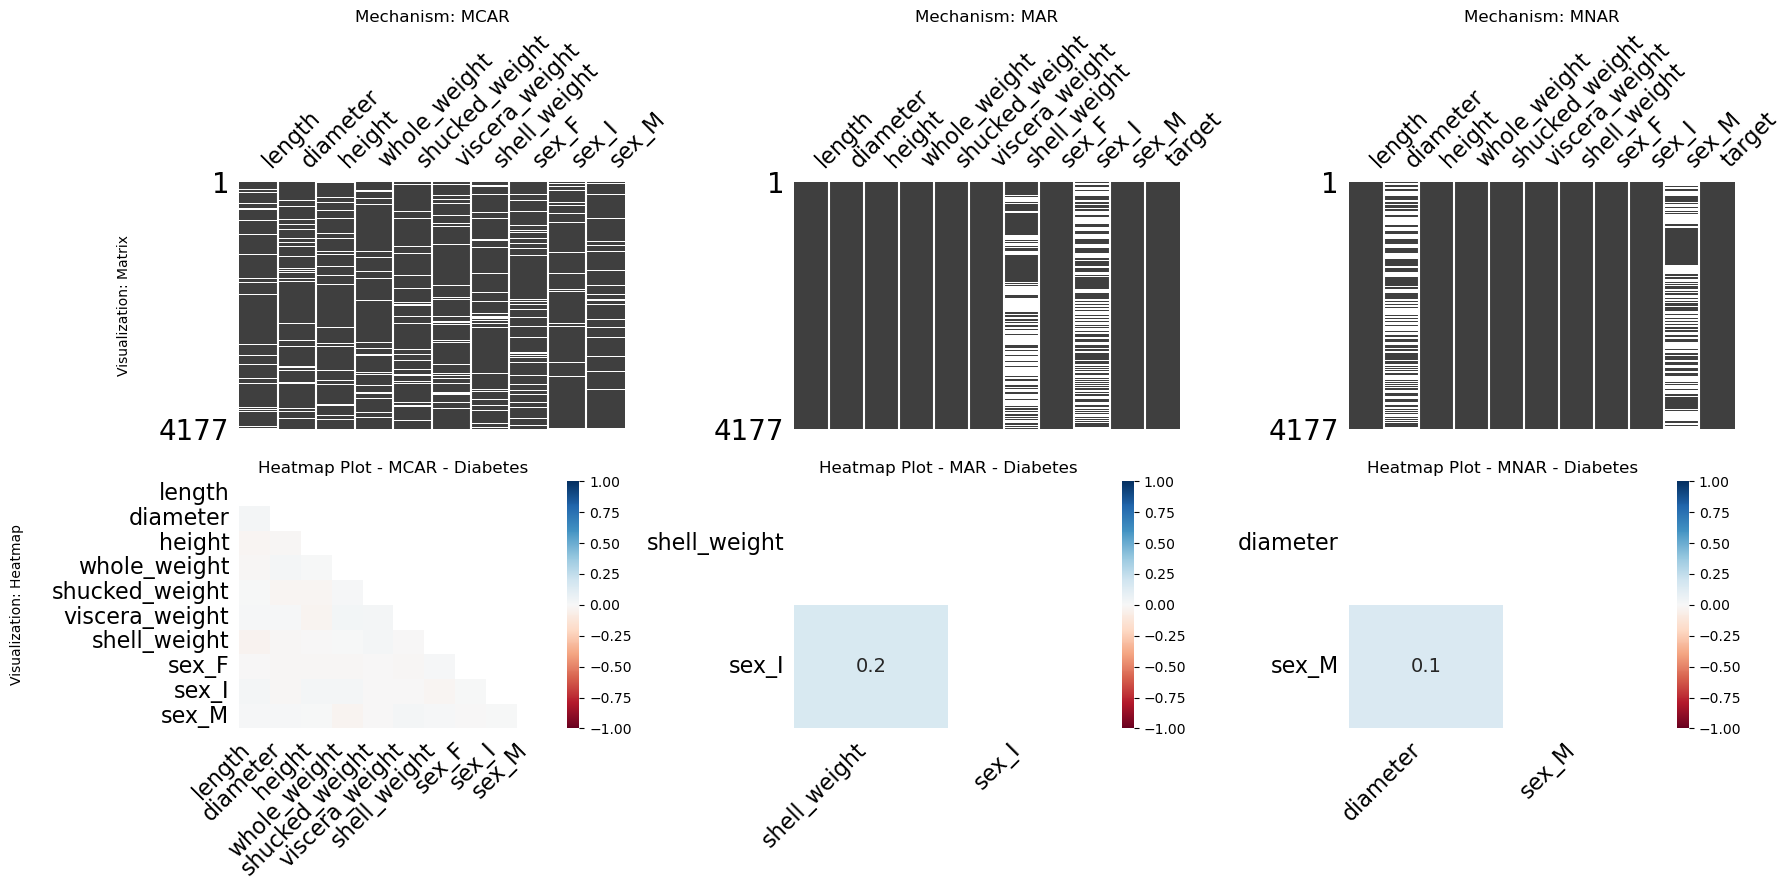

In [16]:
plot_mechanisms_missingno(df_abalone, 
                          mechanisms_df_dict={"MCAR": df_abalone_mcar, "MAR": df_abalone_mar, "MNAR": df_abalone_mnar}, 
                          visualization_type=["matrix", "heatmap"], 
                          figsize=(18, 9))

As we can see in the plots above, 
- MCAR (1st col): The missing values are randomly distributed across the dataset.No significant correlations in the heatmap
- MAR (2nd col): The missingness is related to other observed features in the dataset. In this case the shell_weight and the length are correlated
- MNAR (3rd col): Missingness is non-random and depends on the missing variable itself or other unobserved data. In this case the shell_weight and shicked_weigth features are correlated

## Approaches to Handle Missing Data

<div align="center">
  <img src="handling_missing_data.png" width="1000" >
</div>



There's four main ways to handle missing data:

*   **Case Deletion:** In theory it should only be applied with MCAR 

*   **Missing Data Imputation:**
    *   **Statistical Imputation:** If the mechanism is not MCAR, the imputation might be biased.
        *   **Multiple Imputation(MICE):** is one option, and in theory should only be applied with MAR(eventhoug it has obtained good results with MNAR)
    *   **Machine Learning Imputation** 
        *   **KNN Imputation:** is suitable for MAR and MNAR
        *   **Generative AI-Based Imputation:** is suitable for MAR and MCAR, and has achieved good results with MNAR

*   **Maximum Likelihood:** 

*   **Machine Learning Without Estimation:** Using algorithms that can handle missing data, like Random Forest, Decision Trees, and XGBoost

The evaluation of data imputation can be done in multiple fronts:
<div align="center">
  <img src="evaluating_data_imputation.png" width="1000" >
</div>


*   **Evaluating Predictive Accuracy (PAC)** - For this, we'll use the Mean Squared Error
*   **Evaluating Distributional Accuracy (DAC)** - For this, we'll use the Kolmogorov-Smirnov Distance
*   **Evaluating Classification Error (CE)** - For this, we'll use the F1 Score


Let's start implementing these approaches and evaluate their performance.
## Impact of Missing Data Mechanisms on Performance


In [21]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import  KNNImputer, SimpleImputer, IterativeImputer
from sklearn.linear_model import LinearRegression
from fancyimpute import SoftImpute
import contextlib
import io


def apply_mean_mode_imputation(df, strategy='mean'):
    imputer = SimpleImputer(missing_values=np.nan, strategy=strategy)
    imputed_data = imputer.fit_transform(df)
    return pd.DataFrame(imputed_data, columns=df.columns, index=df.index)

def apply_mice_imputation(df):
    mice_imputer = IterativeImputer(random_state=42, estimator=LinearRegression())
    imputed_data = mice_imputer.fit_transform(df)
    return pd.DataFrame(imputed_data, columns=df.columns, index=df.index)

def apply_knn_imputation(df):
    knn_imputer = KNNImputer(n_neighbors=5)
    imputed_data = knn_imputer.fit_transform(df)
    return pd.DataFrame(imputed_data, columns=df.columns, index=df.index)

def apply_generative_ai_imputation(df):
    softImpute = SoftImpute()
    with contextlib.redirect_stdout(io.StringIO()):
        imputed_data = softImpute.fit_transform(df)
    return pd.DataFrame(imputed_data, columns=df.columns, index=df.index)


imputation_methods = {
    "Mean": lambda df: apply_mean_mode_imputation(df, strategy='mean'),
    "MICE": apply_mice_imputation,
    "KNN": apply_knn_imputation,
    "SoftImpute": apply_generative_ai_imputation
}

missing_data_datasets_diabetes = {
    "MCAR": df_diabetes_mcar.copy(),
    "MAR": df_diabetes_mar.copy(),
    "MNAR": df_diabetes_mnar.copy()
}

missing_data_datasets_abalone = {
    "MCAR": df_abalone_mcar.copy(),
    "MAR": df_abalone_mar.copy(),
    "MNAR": df_abalone_mnar.copy()
}

original_datasets = {
    "Diabetes": X_diabetes.copy(),
    "Abalone": X_abalone.copy()
}

missing_datasets = {
    "Diabetes": missing_data_datasets_diabetes,
    "Abalone": missing_data_datasets_abalone
}

In [22]:
from sklearn.metrics import mean_squared_error
import warnings
from scipy.stats import kstest
import numpy as np

def calculate_mse(original_df, imputed_df):
    # Ensure both dataframes have the same columns for MSE calculation
    common_cols = list(original_df.columns.intersection(imputed_df.columns))
    return mean_squared_error(original_df[common_cols], imputed_df[common_cols])

def calculate_ks_distance(original_df, imputed_df):
    ks_distances = []
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning)
        for col in original_df.columns:
            if col in imputed_df.columns:
                ks_stat, _ = kstest(original_df[col].dropna(), imputed_df[col].dropna(), method='auto')
                ks_distances.append(ks_stat)
    return np.mean(ks_distances) if ks_distances else 0

evaluation_metrics = {
    "PAC (MSE)": calculate_mse,
    "DAC (KS Distance)": calculate_ks_distance,
}

results = {}

for dataset_name in ["Diabetes", "Abalone"]:
    results[dataset_name] = {}
    original_data = original_datasets[dataset_name]
    missing_data_mechanism_datasets = missing_datasets[dataset_name]

    for mechanism_name, df_missing in missing_data_mechanism_datasets.items():
        results[dataset_name][mechanism_name] = {}
        for method_name, imputation_func in imputation_methods.items():
            df_imputed = imputation_func(df_missing.copy())
            results[dataset_name][mechanism_name][method_name] = {}
            for metric_name, metric_func in evaluation_metrics.items():
                results[dataset_name][mechanism_name][method_name][metric_name] = metric_func(original_data.fillna(original_data.mean()), df_imputed) 

d:\Programs\MiniConda\envs\icd_project\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
d:\Programs\MiniConda\envs\icd_project\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [23]:
def plot_evaluation_results(results, dataset_name, metric_names):
    mechanisms = list(results[dataset_name].keys())
    methods = list(results[dataset_name][mechanisms[0]].keys())
    num_mechanisms = len(mechanisms)
    num_methods = len(methods)
    num_metrics = len(metric_names)

    fig, axes = plt.subplots(1, num_metrics, figsize=(15, 6)) 

    for idx, metric_name in enumerate(metric_names):
        ax = axes[idx] if num_metrics > 1 else axes 
        metric_values = np.zeros((num_mechanisms, num_methods))
        for i, mechanism in enumerate(mechanisms):
            for j, method in enumerate(methods):
                metric_values[i, j] = results[dataset_name][mechanism][method][metric_name]

        bar_width = 0.15
        bar_positions = np.arange(num_mechanisms)

        for j, method in enumerate(methods):
            ax.bar(bar_positions + j * bar_width, metric_values[:, j], bar_width, label=method)

        ax.set_xticks(bar_positions + bar_width * (num_methods - 1) / 2)
        ax.set_xticklabels(mechanisms)
        ax.set_ylabel(metric_name)
        ax.set_xlabel("Missing Data Mechanism")
        ax.set_title(f"{metric_name} Comparison for {dataset_name} Dataset")
        if idx == num_metrics -1: 
            ax.legend()

    plt.tight_layout()
    plt.show()

metric_names_to_plot = ["PAC (MSE)", "DAC (KS Distance)"] 

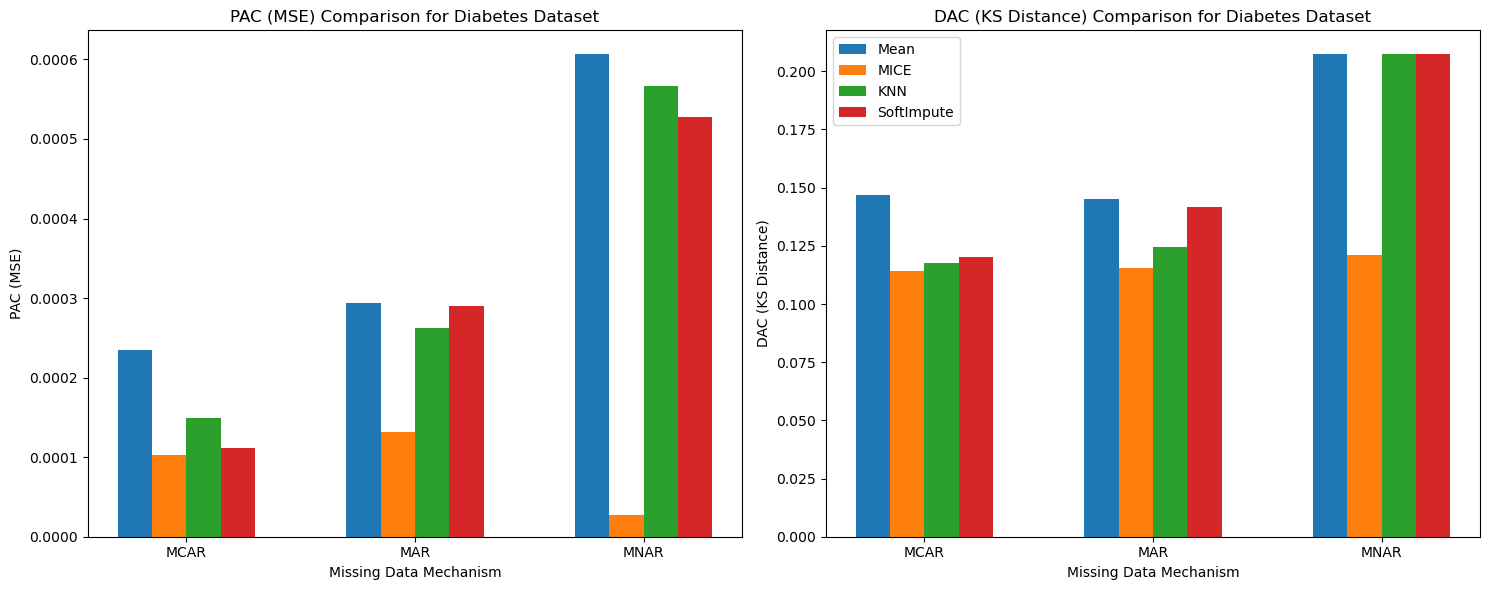

In [24]:
plot_evaluation_results(results, "Diabetes", metric_names_to_plot)

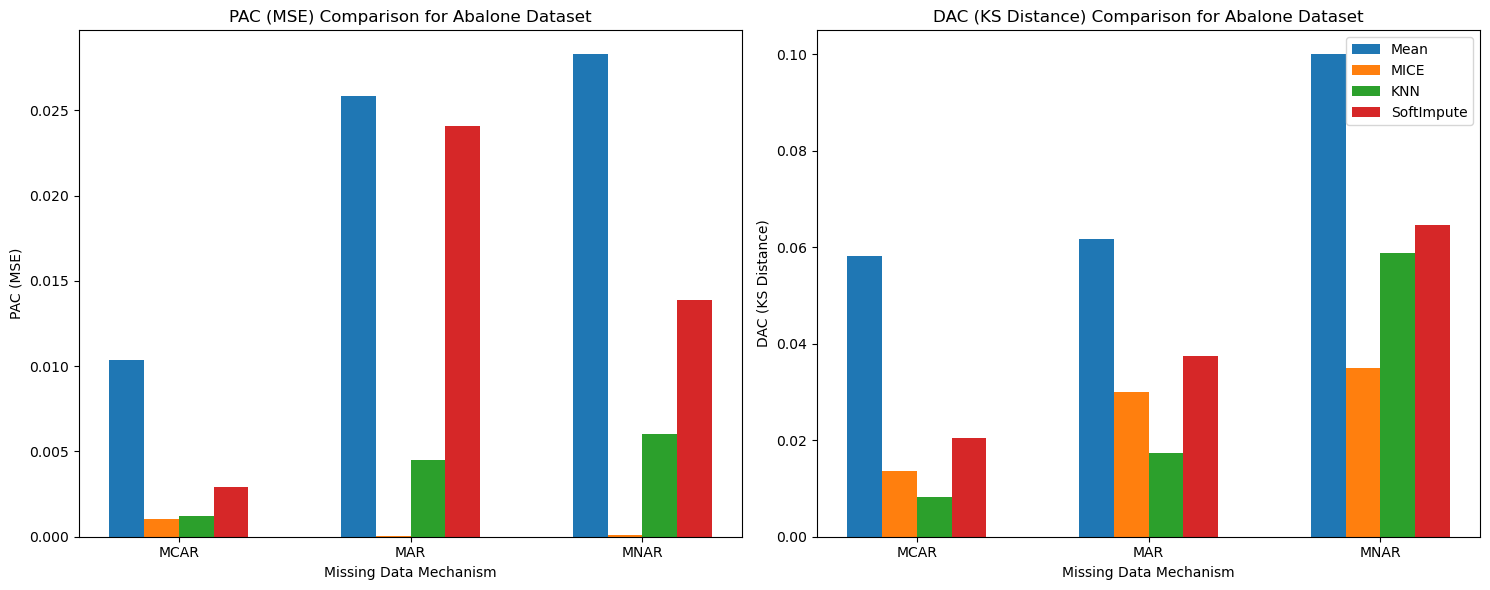

In [149]:
plot_evaluation_results(results, "Abalone", metric_names_to_plot)